<a href="https://colab.research.google.com/github/jeppusonal/Real-Estate-Price-Prediction-Chicago-Housing-Dataset-/blob/main/Chicago_Real_Estate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **LOADING & UNDERSTANDING THE DATA**

In [ ]:
# Loading the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import chi2_contingency

In [ ]:
# Loading the dataset
data=pd.read_csv('/content/real_estate_data_chicago.csv')
data.head()

,type,text,year_built,beds,baths,baths_full,baths_half,garage,lot_sqft,sqft,stories,lastSoldPrice,soldOn,listPrice,status
0,single_family,"Come check out this amazing, move-in ready, 5 ...",1951.0,4.0,4.0,3.0,1.0,1.0,5615.0,3000.0,2.0,NaN,NaN,750000.0,for_sale
1,single_family,Move in ready 2 story Mount Greenwood home on ...,1922.0,4.0,3.0,2.0,1.0,2.0,6566.0,2900.0,2.0,105000.0,1991-04-16,499900.0,for_sale
2,single_family,Investor Special MONEY MAKING Gem. This is you...,1947.0,4.0,2.0,2.0,NaN,3.0,5375.0,1170.0,2.0,60000.0,2019-10-28,325600.0,for_sale
3,single_family,Renovated Brick 1.5 story house with finished ...,1945.0,4.0,3.0,2.0,1.0,2.0,6138.0,2511.0,2.0,170000.0,1996-05-30,620000.0,for_sale
4,single_family,This almost 3000sq foot home was thoughtfully ...,1907.0,4.0,4.0,2.0,2.0,2.0,8476.0,2870.0,3.0,NaN,NaN,850000.0,for_sale


In [ ]:
# Checking the size of the dataset
data.shape

(2000, 15)

In [ ]:
# Summary of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   type           2000 non-null   object 
 1   text           1992 non-null   object 
 2   year_built     1790 non-null   float64
 3   beds           1940 non-null   float64
 4   baths          1999 non-null   float64
 5   baths_full     1937 non-null   float64
 6   baths_half     592 non-null    float64
 7   garage         1282 non-null   float64
 8   lot_sqft       992 non-null    float64
 9   sqft           1447 non-null   float64
 10  stories        1620 non-null   float64
 11  lastSoldPrice  1415 non-null   float64
 12  soldOn         1415 non-null   object 
 13  listPrice      1994 non-null   float64
 14  status         2000 non-null   object 
dtypes: float64(11), object(4)
memory usage: 234.5+ KB


In [ ]:
# Key Descriptive Statistics
data.describe()

,year_built,beds,baths,baths_full,baths_half,garage,lot_sqft,sqft,stories,lastSoldPrice,listPrice
count,1790.000000,1940.00000,1999.00000,1937.000000,592.000000,1282.000000,9.920000e+02,1447.000000,1620.000000,1.415000e+03,1.994000e+03
mean,1946.050838,3.28866,2.43972,2.155911,1.189189,2.131825,7.156209e+03,2069.910159,7.183951,3.685186e+05,6.012279e+05
std,38.985904,1.75855,1.45649,1.106637,0.553119,11.367288,6.861154e+04,1691.518319,13.036822,6.156896e+05,1.202400e+06
min,1856.000000,0.00000,0.00000,1.000000,1.000000,1.000000,1.000000e+00,372.000000,1.000000,6.000000e+02,1.500000e+02
25%,1916.000000,2.00000,2.00000,1.000000,1.000000,1.000000,3.125000e+03,1170.000000,2.000000,1.117500e+05,2.250000e+05
50%,1943.000000,3.00000,2.00000,2.000000,1.000000,2.000000,3.750000e+03,1550.000000,2.000000,2.180000e+05,3.499000e+05
75%,1970.750000,4.00000,3.00000,3.000000,1.000000,2.000000,5.013000e+03,2355.000000,4.000000,3.950000e+05,5.750000e+05
max,2024.000000,21.00000,13.00000,8.000000,5.000000,400.000000,2.156000e+06,25000.000000,119.000000,7.500000e+06,2.350000e+07


In [ ]:
# Checking for null values
data.isnull().sum()

,0
type,0
text,8
year_built,210
beds,60
baths,1
baths_full,63
baths_half,1408
garage,718
lot_sqft,1008
sqft,553


### **DATA CLEANING**

In [ ]:
# Checking for duplicates
data.duplicated().sum()

2

In [ ]:
# Dropping the duplicates
data.drop_duplicates(inplace=True)
data.shape

(1998, 15)

In [ ]:
# Dropping Columns
data.drop(['text', 'baths_full', 'baths_half'] ,axis=1,inplace=True)
data.head()

,type,year_built,beds,baths,garage,lot_sqft,sqft,stories,lastSoldPrice,soldOn,listPrice,status
0,single_family,1951.0,4.0,4.0,1.0,5615.0,3000.0,2.0,NaN,NaN,750000.0,for_sale
1,single_family,1922.0,4.0,3.0,2.0,6566.0,2900.0,2.0,105000.0,1991-04-16,499900.0,for_sale
2,single_family,1947.0,4.0,2.0,3.0,5375.0,1170.0,2.0,60000.0,2019-10-28,325600.0,for_sale
3,single_family,1945.0,4.0,3.0,2.0,6138.0,2511.0,2.0,170000.0,1996-05-30,620000.0,for_sale
4,single_family,1907.0,4.0,4.0,2.0,8476.0,2870.0,3.0,NaN,NaN,850000.0,for_sale


In [ ]:
# Dropping rows with null values from year_built, listPrice columns
data.dropna(subset=['year_built'], inplace=True)
data.dropna(subset=['listPrice'], inplace=True)
data.head()

,type,year_built,beds,baths,garage,lot_sqft,sqft,stories,lastSoldPrice,soldOn,listPrice,status
0,single_family,1951.0,4.0,4.0,1.0,5615.0,3000.0,2.0,NaN,NaN,750000.0,for_sale
1,single_family,1922.0,4.0,3.0,2.0,6566.0,2900.0,2.0,105000.0,1991-04-16,499900.0,for_sale
2,single_family,1947.0,4.0,2.0,3.0,5375.0,1170.0,2.0,60000.0,2019-10-28,325600.0,for_sale
3,single_family,1945.0,4.0,3.0,2.0,6138.0,2511.0,2.0,170000.0,1996-05-30,620000.0,for_sale
4,single_family,1907.0,4.0,4.0,2.0,8476.0,2870.0,3.0,NaN,NaN,850000.0,for_sale


### **HANDLING MISSING VALUES**

In [ ]:
# Checking for null values
data.isnull().sum()

,0
type,0
year_built,0
beds,9
baths,0
garage,580
lot_sqft,908
sqft,441
stories,302
lastSoldPrice,524
soldOn,524


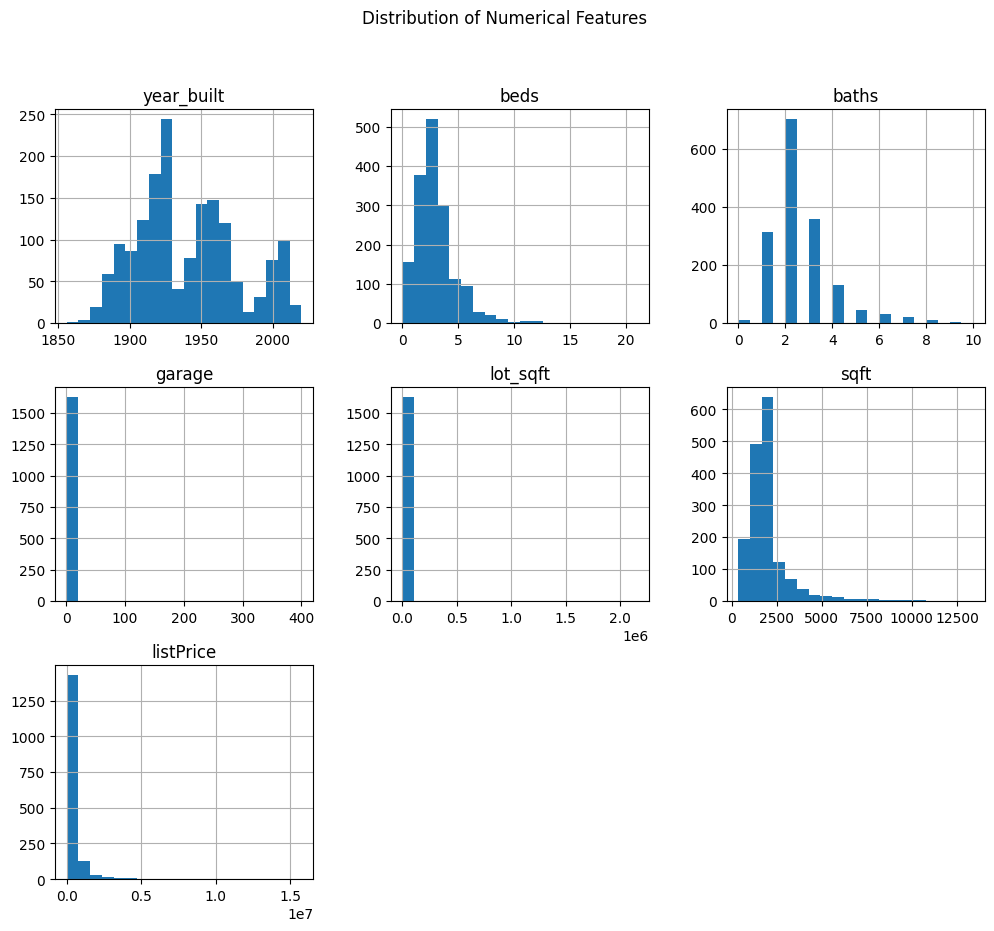

In [ ]:
data[['year_built', 'beds', 'baths', 'garage', 'lot_sqft', 'sqft', 'listPrice']].hist(figsize=(12, 10), bins=20)
plt.suptitle('Distribution of Numerical Features')
plt.show()


In [ ]:
# filling the null values with 0 assuming they haven't been sold before
data.loc[data.index == 'lastSoldPrice'] = data.loc[data.index == 'lastSoldPrice'].fillna(0)
data.loc[data.index == 'soldOn'] = data.loc[data.index == 'soldOn'].fillna(0)

In [ ]:
# Handle missing values
selected_columns=['beds','garage','stories']
for column in selected_columns:
    # Calculate the mean value for the current column
    mean_value = data[column].mean()
    data[column] = data[column].fillna(mean_value).round(0)

In [ ]:
columns = ['lot_sqft', 'sqft', 'lastSoldPrice']

# Replace null values with the mean of each column and round in one step
for col in columns:
    mean_value = data[col].mean()
    data.loc[:, col] = data[col].fillna(mean_value).round(0)

### **FEATURE ENGINEERING**

In [ ]:
data.columns

Index(['type', 'year_built', 'beds', 'baths', 'garage', 'lot_sqft', 'sqft',
       'stories', 'lastSoldPrice', 'soldOn', 'listPrice', 'status'],
      dtype='object')

In [ ]:
data['soldOn'] = data['soldOn'].fillna(0)
# Convert the 'soldOn' column to datetime format
data['soldOn'] = pd.to_datetime(data['soldOn'])

# Extract the year from the 'soldOn' datetime column
data['soldOn'] = data['soldOn'].dt.year

# Convert the extracted year to an integer type
data['soldOn'] = data['soldOn'].astype(int)

In [ ]:
# Creating new column ' property_age ' from other columns
data['property_age']=data['soldOn'] - data['year_built']
data=data[data['property_age']>=0]

In [ ]:
data.isnull().sum()

,0
type,0
year_built,0
beds,0
baths,0
garage,0
lot_sqft,0
sqft,0
stories,0
lastSoldPrice,0
soldOn,0


In [ ]:
print(data.shape)

(1626, 13)


### **OUTLIER DETECTION & TREATMENT**

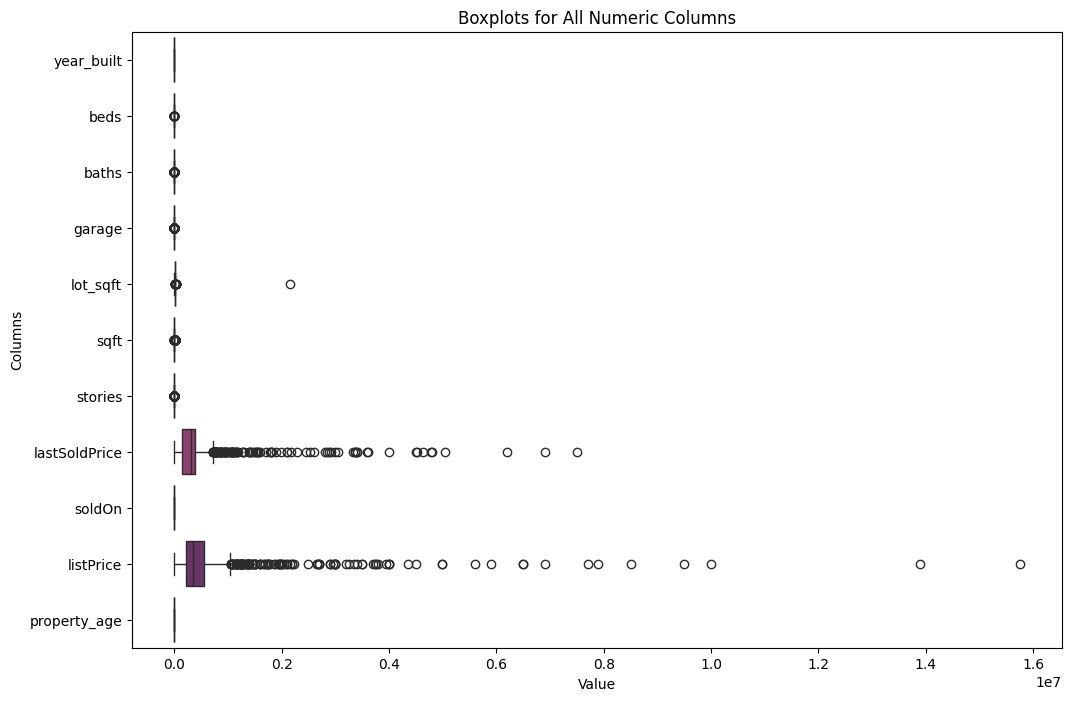

In [ ]:
# Plotting boxplot to check for outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=data, orient="h", palette="flare")
plt.title('Boxplots for All Numeric Columns')
plt.xlabel('Value')
plt.ylabel('Columns')
plt.show()

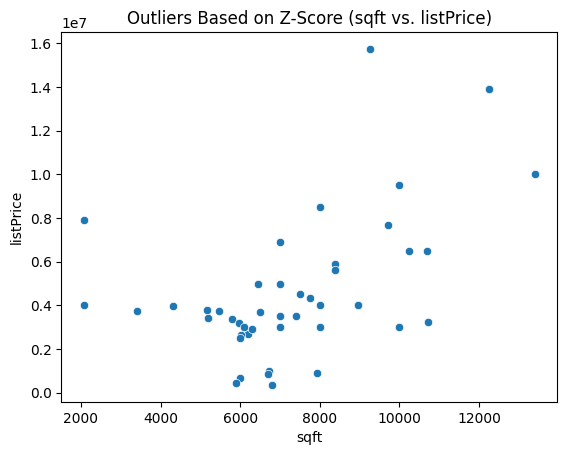

In [ ]:
from scipy import stats
import numpy as np

# Calculate z-scores for 'sqft' and 'listPrice' separately
data['z_score_sqft'] = np.abs(stats.zscore(data['sqft'].dropna()))
data['z_score_listPrice'] = np.abs(stats.zscore(data['listPrice'].dropna()))

# Identify outliers based on either 'sqft' or 'listPrice' having a z-score > 3
outliers = data[(data['z_score_sqft'] > 3) | (data['z_score_listPrice'] > 3)]

# Plotting the outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='sqft', y='listPrice', data=outliers)
plt.title('Outliers Based on Z-Score (sqft vs. listPrice)')
plt.show()

In [ ]:
def treat_outliers_iqr(df):
    data = df.copy()

    # Iterate over numerical columns
    for column in data.select_dtypes(include=['int', 'float']).columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)

        # Calculate the interquartile range (IQR)
        IQR = Q3 - Q1

        # Define the lower and upper bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find values outside the bounds and replace them with NaN
        outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
        data.loc[outliers, column] = data[column].mean()

    return data

# Apply the function to your dataset
data_clean = treat_outliers_iqr(data)

<ipython-input-24-c07b2af21849>:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2000.0405904059041' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[outliers, column] = data[column].mean()


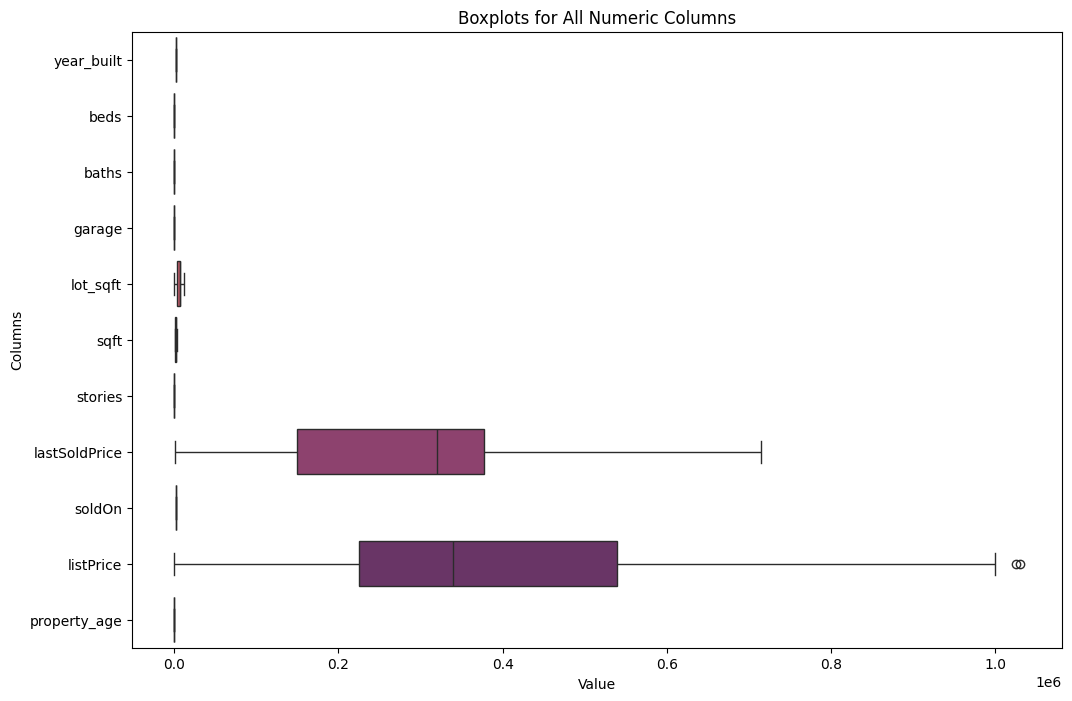

In [ ]:
# Plotting boxplot to check for outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=data_clean, orient="h", palette="flare")
plt.title('Boxplots for All Numeric Columns')
plt.xlabel('Value')
plt.ylabel('Columns')
plt.show()

### **EXPLORATORY DATA ANALYSIS**

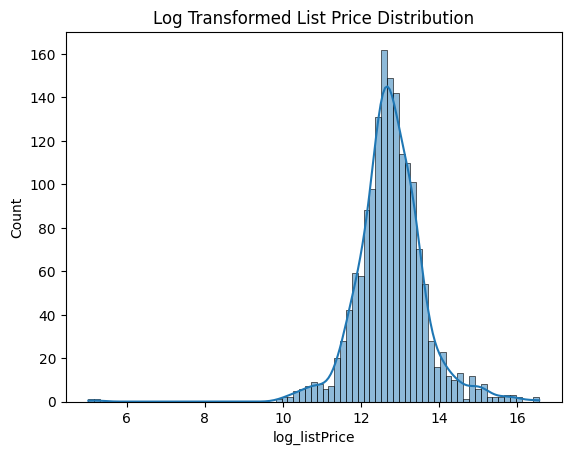

In [ ]:
import numpy as np
data['log_listPrice'] = np.log1p(data['listPrice'])

sns.histplot(data['log_listPrice'], kde=True)
plt.title('Log Transformed List Price Distribution')
plt.show()


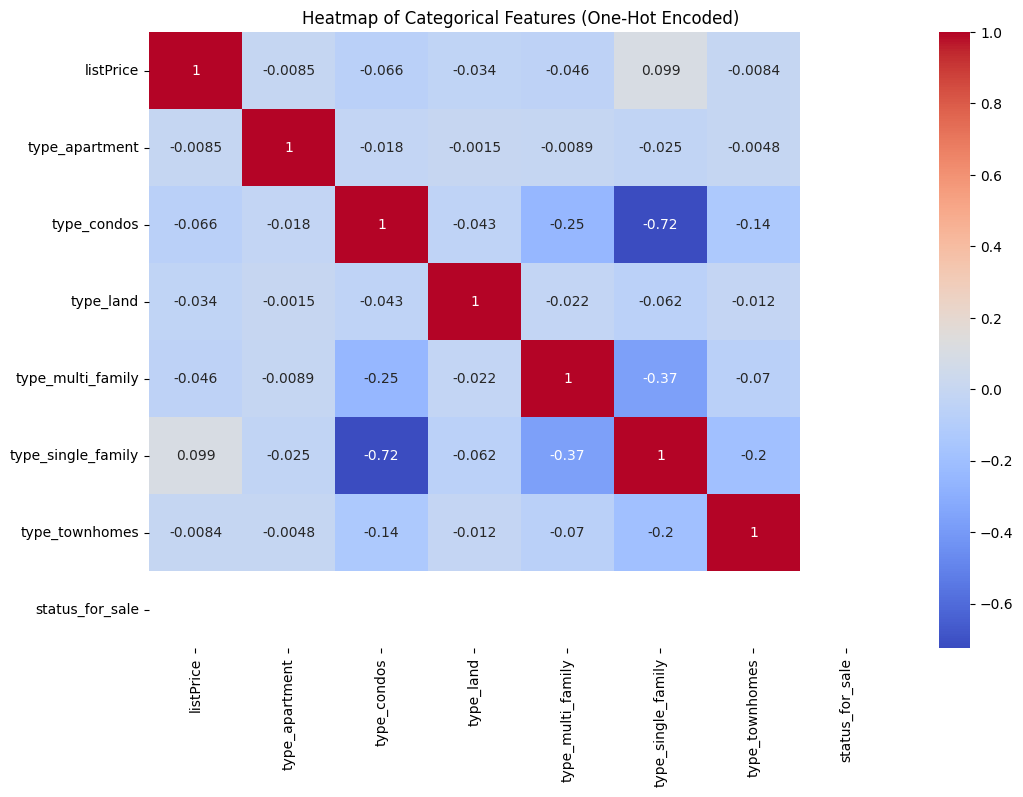

In [ ]:
categorical_data = pd.get_dummies(data[['type', 'status']])
combined_data = pd.concat([data[['listPrice']], categorical_data], axis=1)

plt.figure(figsize=(12,8))
sns.heatmap(combined_data.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of Categorical Features (One-Hot Encoded)')
plt.show()


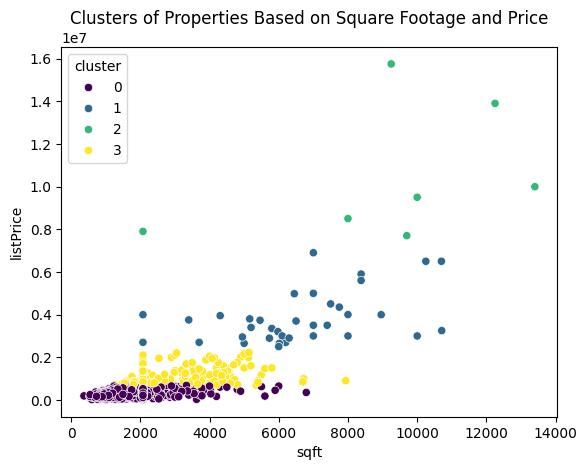

In [ ]:
from sklearn.cluster import KMeans
features = data[['sqft', 'listPrice']].dropna()

kmeans = KMeans(n_clusters=4, random_state=0).fit(features)
data['cluster'] = kmeans.labels_

sns.scatterplot(x=data['sqft'], y=data['listPrice'], hue=data['cluster'], palette='viridis')
plt.title('Clusters of Properties Based on Square Footage and Price')
plt.show()


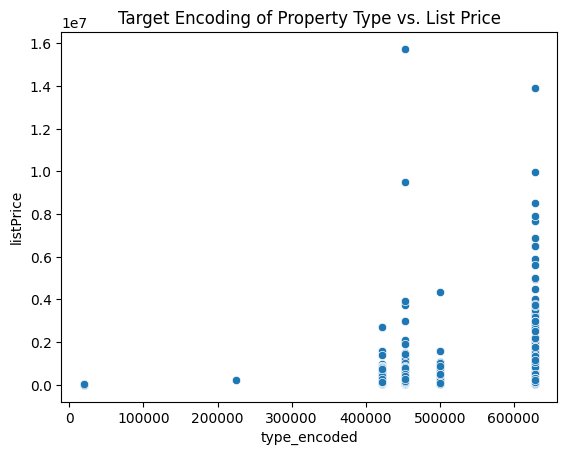

In [ ]:
data['type_encoded'] = data.groupby('type')['listPrice'].transform('mean')
data['status_encoded'] = data.groupby('status')['listPrice'].transform('mean')

sns.scatterplot(x='type_encoded', y='listPrice', data=data)
plt.title('Target Encoding of Property Type vs. List Price')
plt.show()

In [ ]:
# Exploratory Data Analysis
def plot_price_by_feature(df, feature, title):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=data_clean, x=feature, y='lastSoldPrice', errorbar=None, palette="dark:#5A9_r")
    plt.title(title)
    plt.xlabel(feature)
    plt.ylabel('Last Sold Price')
    plt.show()

<ipython-input-26-8397ce4d9bde>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_clean, x=feature, y='lastSoldPrice', errorbar=None, palette="dark:#5A9_r")


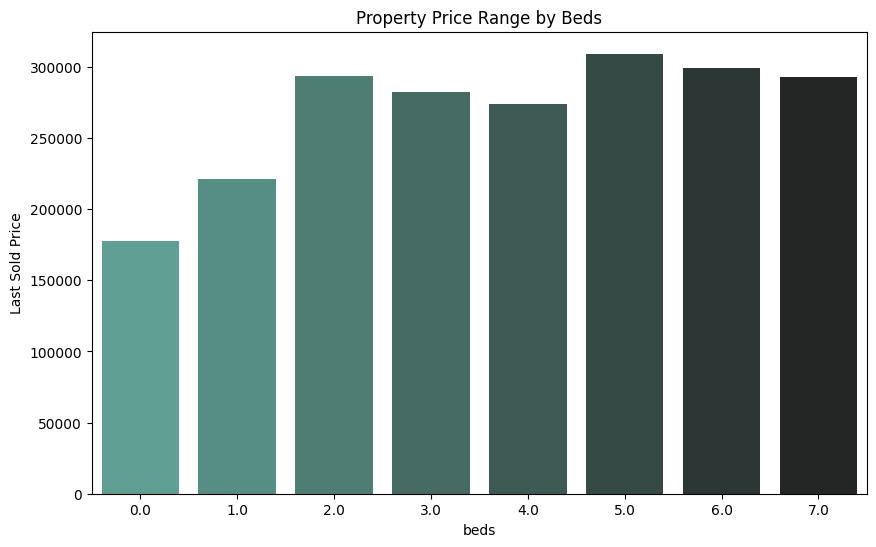

In [ ]:
data_clean['beds'] = data_clean['beds'].round()
# Alternatively, converting to integer (if rounding isn't needed):
# data['beds'] = data['beds'].astype(int)
plot_price_by_feature(data_clean, 'beds', 'Property Price Range by Beds')

<ipython-input-28-fb41c92f8ad3>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=median_price_by_baths, x='baths', y='lastSoldPrice', palette='Spectral')


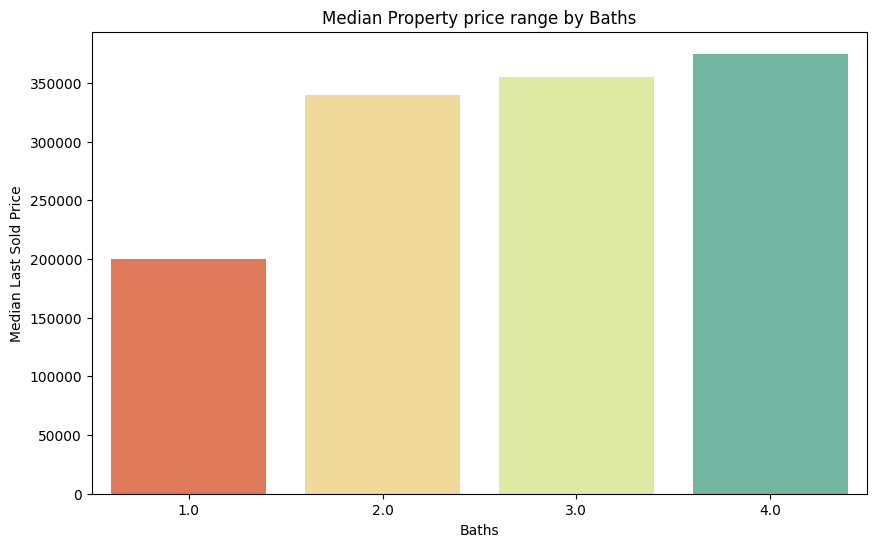

In [ ]:
# Rounding or converting the 'baths' column to ensure no floating-point issues
data_clean['baths'] = data_clean['baths'].round()

# Grouping by 'baths' and calculating the median last sold price
median_price_by_baths = data_clean.groupby('baths')['lastSoldPrice'].median().reset_index()

# Plotting the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=median_price_by_baths, x='baths', y='lastSoldPrice', palette='Spectral')
plt.title('Median Property price range by Baths')
plt.xlabel('Baths')
plt.ylabel('Median Last Sold Price')
plt.show()

In [ ]:
# # Installing package
# !pip install dataprep

In [ ]:
# # EDA dataprep report
# from dataprep.eda import create_report
# report = create_report(data)
# report.show()

Bivariate analysis of correlated variables to uncover patterns

<ipython-input-31-91a9196322a6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=median_price_by_type, x='type', y='lastSoldPrice', palette='Spectral')


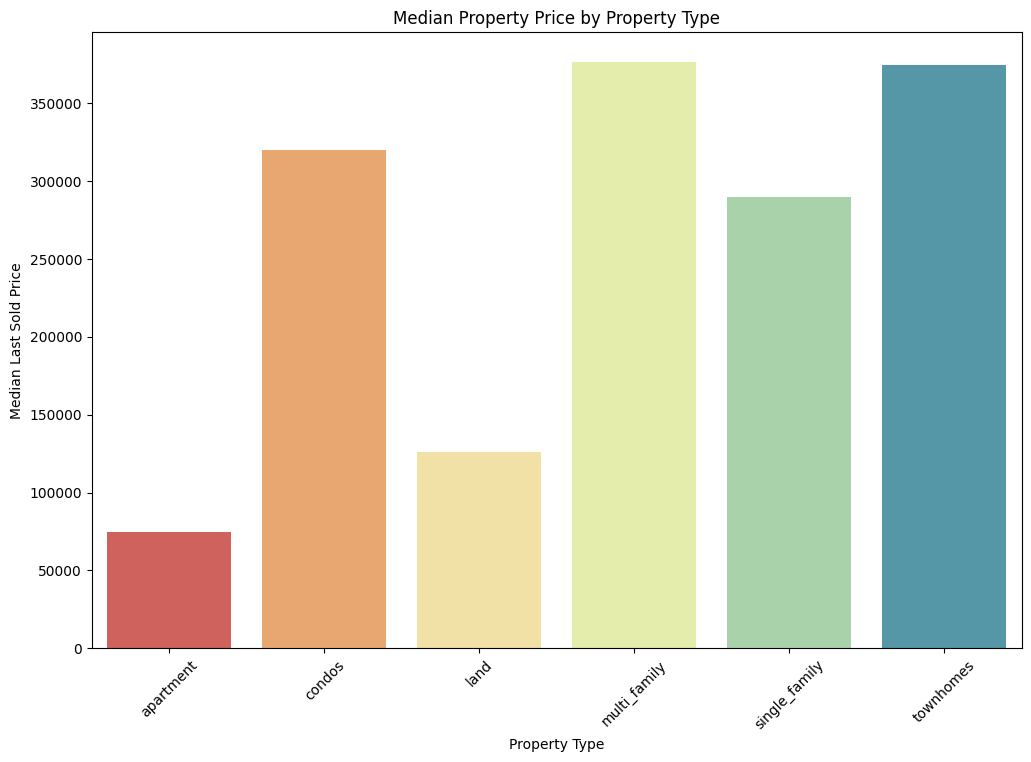

In [ ]:
# property price range by property type
median_price_by_type = data_clean.groupby('type')['lastSoldPrice'].median().reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(data=median_price_by_type, x='type', y='lastSoldPrice', palette='Spectral')
plt.title('Median Property Price by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Median Last Sold Price')
plt.xticks(rotation=45)
plt.show()

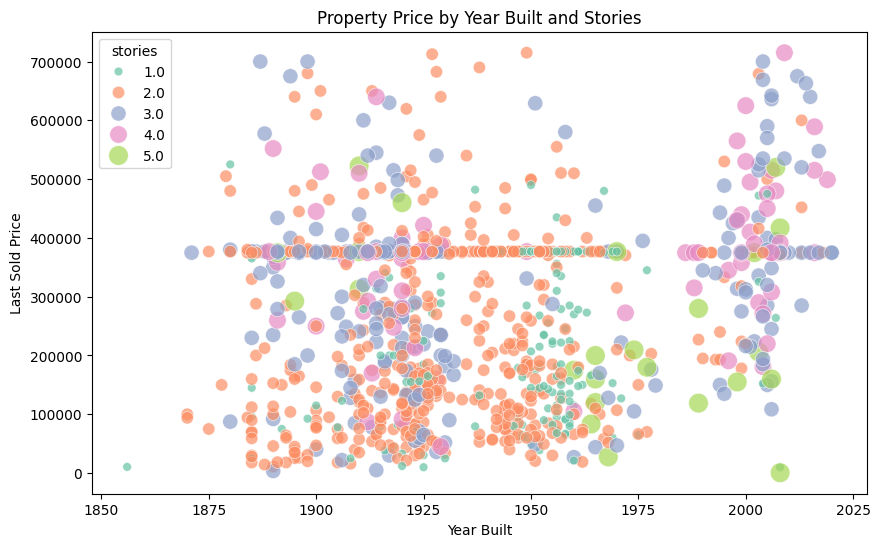

In [ ]:
# Scatterplot for year built and last sold price, and hue for number of stories
import matplotlib.pyplot as plt
import seaborn as sns
data_cleaned = data_clean[data_clean['stories'].isin([1,2,3,4,5])]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_cleaned, x='year_built', y='lastSoldPrice', hue='stories', palette='Set2', size='stories', sizes=(40, 200), alpha=0.7)
plt.title('Property Price by Year Built and Stories')
plt.xlabel('Year Built')
plt.ylabel('Last Sold Price')
plt.show()

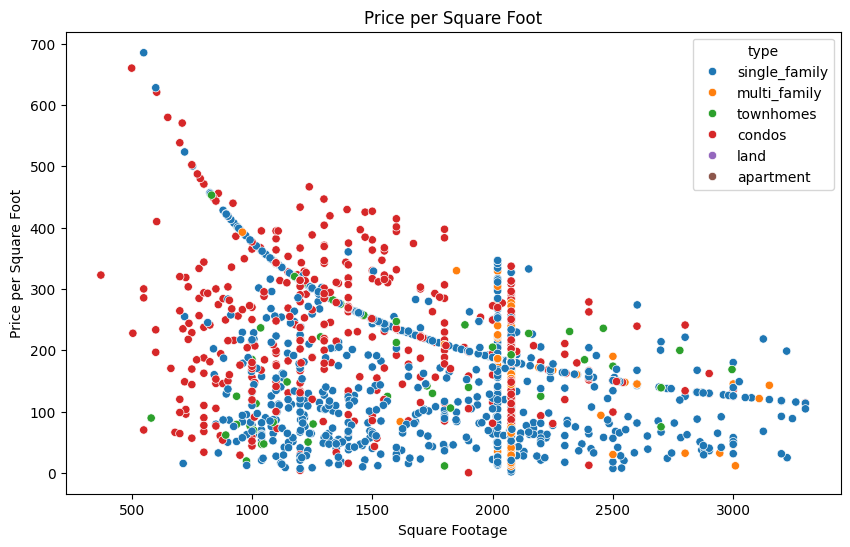

In [ ]:
# property price per square foot
data_clean['price_per_sqft'] = data_clean['lastSoldPrice'] / data_clean['sqft']
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_clean, x='sqft', y='price_per_sqft', hue='type')
plt.title('Price per Square Foot')
plt.xlabel('Square Footage')
plt.ylabel('Price per Square Foot')
plt.show()

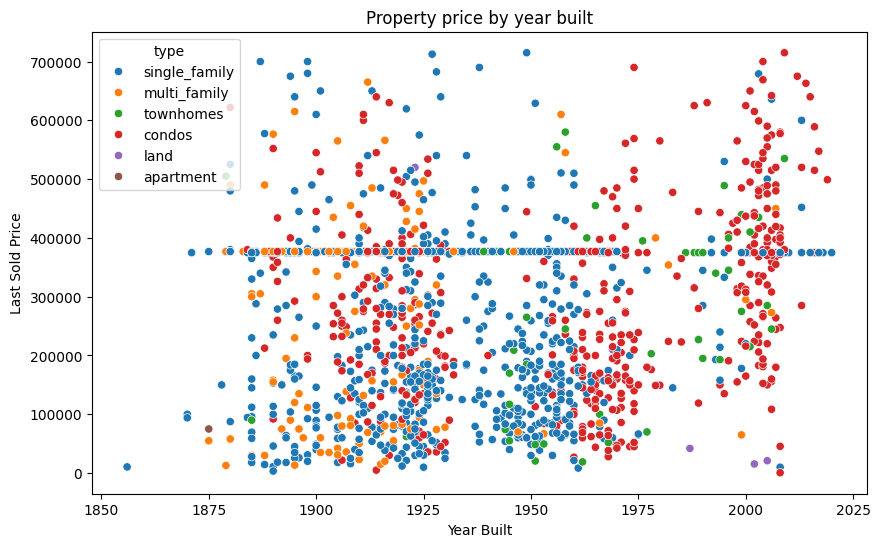

In [ ]:
#Property price by year built
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_clean, x='year_built', y='lastSoldPrice', hue='type')
plt.title('Property price by year built')
plt.xlabel('Year Built')
plt.ylabel('Last Sold Price')
plt.show()

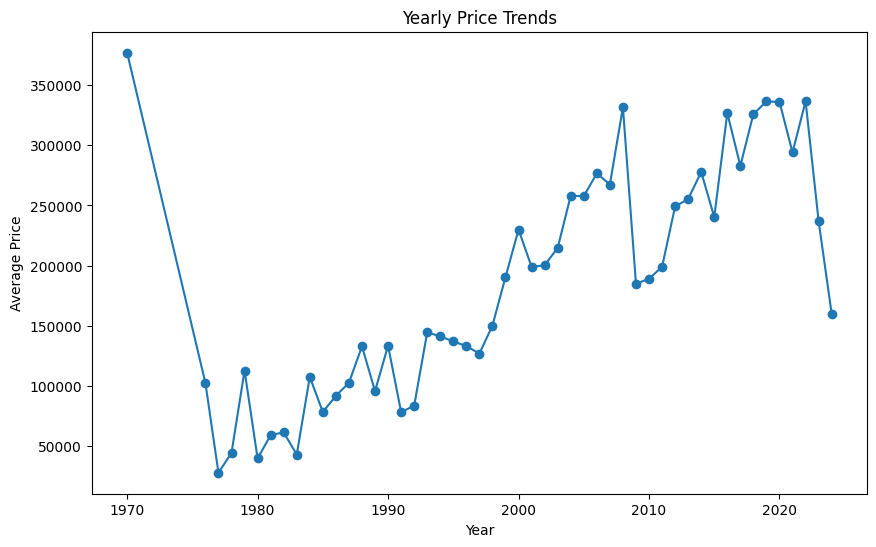

In [ ]:
#yearly price trends
yearly_prices = data_clean.groupby('soldOn')['lastSoldPrice'].mean()
plt.figure(figsize=(10, 6))
yearly_prices.plot(marker='o')
plt.title('Yearly Price Trends')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.show()

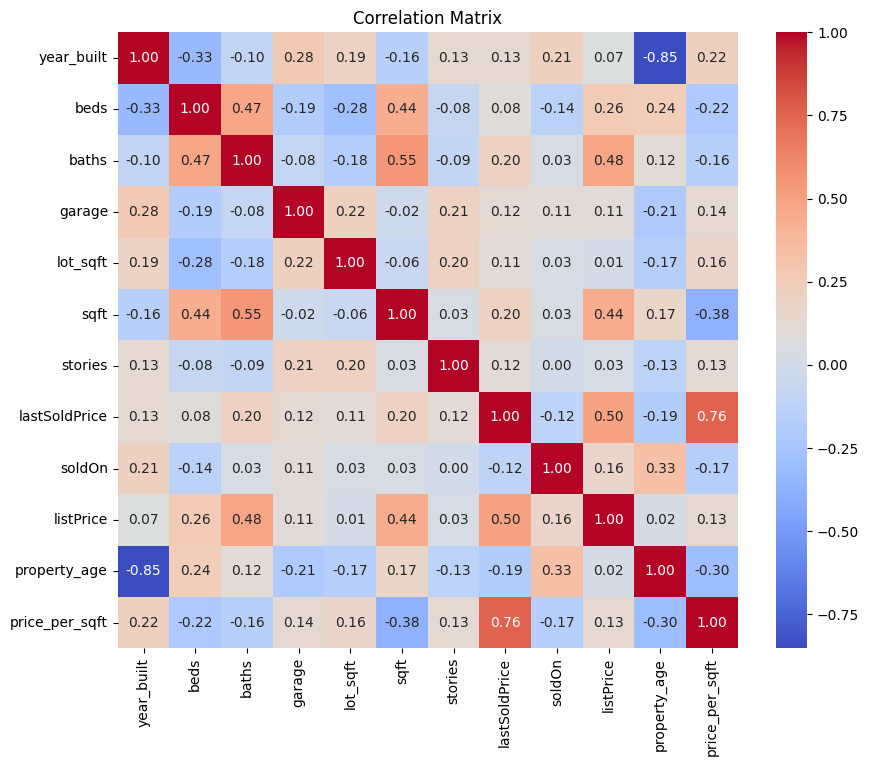

In [ ]:
# Correlation analysis: Pearson correlation coefficient
numerical_data = data_clean.select_dtypes(include=['number'])

correlation_matrix = numerical_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### **Checking Statistical Significance of variables through P_value test**

In [ ]:
from scipy import stats

# Perform an independent t-test between 'lastSoldPrice' and 'sqft' columns
t_statistics, p_value = stats.ttest_ind(data['lastSoldPrice'], data['sqft'])
print("T-statistics:", t_statistics)

# Format the p-value to 10 decimal places
normal_format = "{:.10f}".format(p_value)
print("P-value:", normal_format)


T-statistics: 27.566988149254627
P-value: 0.0000000000


In [ ]:
# Perform an independent t-test between 'lastSoldPrice' and 'beds' columns
t_statistics, p_value = stats.ttest_ind(data['lastSoldPrice'], data['beds'])
print("T-statistics:", t_statistics)

# Format the p-value to 10 decimal places
normal_format="{:.10f}".format(p_value)
print("P-value:", normal_format)

T-statistics: 27.716213897006497
P-value: 0.0000000000


In [ ]:
# Perform an independent t-test between 'lastSoldPrice' and 'baths' columns
t_statistics, p_value = stats.ttest_ind(data['lastSoldPrice'], data['baths'])
print("T-statistics:", t_statistics)

# Format the p-value to 10 decimal places
normal_format="{:.10f}".format(p_value)
print("P-value:", normal_format)

T-statistics: 27.71627577260133
P-value: 0.0000000000


In [ ]:
# Perform an independent t-test between 'lastSoldPrice' and 'garage' columns
t_statistics, p_value = stats.ttest_ind(data['lastSoldPrice'], data['garage'])
print("T-statistics:", t_statistics)

# Format the p-value to 10 decimal places
normal_format="{:.10f}".format(p_value)
print("P-value:", normal_format)

T-statistics: 27.716301363812786
P-value: 0.0000000000


In [ ]:
# Perform an independent t-test between 'lastSoldPrice' and 'stories' columns
t_statistics, p_value = stats.ttest_ind(data['lastSoldPrice'], data['stories'])
print("T-statistics:", t_statistics)

# Format the p-value to 10 decimal places
normal_format="{:.10f}".format(p_value)
print("P-value:", normal_format)

T-statistics: 27.71592169778852
P-value: 0.0000000000


In [ ]:
data_clean.head()

,type,year_built,beds,baths,garage,lot_sqft,sqft,stories,lastSoldPrice,soldOn,listPrice,status,property_age,price_per_sqft
0,single_family,1951.0,4.0,4.0,2.117466,5615.0,3000.0,2.0,376800.0,1970.0,750000.0,for_sale,19.0,125.600000
1,single_family,1922.0,4.0,3.0,2.000000,6566.0,2900.0,2.0,105000.0,1991.0,499900.0,for_sale,69.0,36.206897
2,single_family,1947.0,4.0,2.0,2.117466,5375.0,1170.0,2.0,60000.0,2019.0,325600.0,for_sale,72.0,51.282051
3,single_family,1945.0,4.0,3.0,2.000000,6138.0,2511.0,2.0,170000.0,1996.0,620000.0,for_sale,51.0,67.702111
4,single_family,1907.0,4.0,4.0,2.000000,8476.0,2870.0,3.0,376800.0,1970.0,850000.0,for_sale,63.0,131.289199


In [ ]:
# Perform one-hot encoding on the 'type' column
data_encoded = pd.get_dummies(data_clean['type'], prefix='type')

# Join the one-hot encoded columns back to the original dataframe
data_final = pd.concat([data_clean, data_encoded], axis=1)

# Drop the original 'type' column if needed
data_final.drop('type', axis=1, inplace=True)

# Convert boolean (if any) to integer (0/1)
data_final = data_final.astype(int, errors='ignore')

# Show the resulting dataframe
data_final.head()

,year_built,beds,baths,garage,lot_sqft,sqft,stories,lastSoldPrice,soldOn,listPrice,status,property_age,price_per_sqft,type_apartment,type_condos,type_land,type_multi_family,type_single_family,type_townhomes
0,1951,4,4,2,5615,3000,2,376800,1970,750000,for_sale,19,125,0,0,0,0,1,0
1,1922,4,3,2,6566,2900,2,105000,1991,499900,for_sale,69,36,0,0,0,0,1,0
2,1947,4,2,2,5375,1170,2,60000,2019,325600,for_sale,72,51,0,0,0,0,1,0
3,1945,4,3,2,6138,2511,2,170000,1996,620000,for_sale,51,67,0,0,0,0,1,0
4,1907,4,4,2,8476,2870,3,376800,1970,850000,for_sale,63,131,0,0,0,0,1,0


In [ ]:
data_final.drop('status', axis=1, inplace=True)
data_final.head()

,year_built,beds,baths,garage,lot_sqft,sqft,stories,lastSoldPrice,soldOn,listPrice,property_age,price_per_sqft,type_apartment,type_condos,type_land,type_multi_family,type_single_family,type_townhomes
0,1951,4,4,2,5615,3000,2,376800,1970,750000,19,125,0,0,0,0,1,0
1,1922,4,3,2,6566,2900,2,105000,1991,499900,69,36,0,0,0,0,1,0
2,1947,4,2,2,5375,1170,2,60000,2019,325600,72,51,0,0,0,0,1,0
3,1945,4,3,2,6138,2511,2,170000,1996,620000,51,67,0,0,0,0,1,0
4,1907,4,4,2,8476,2870,3,376800,1970,850000,63,131,0,0,0,0,1,0


### Splitting the data into features (X) and target (y):

In [ ]:
# Splitting the dataset into features (X) and target variable (y)
X = data_final.drop(columns=['listPrice'])
y = data_final['listPrice']

# Converting categorical columns into dummy variables
#X = pd.get_dummies(X, drop_first=True)

# Splitting the data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Baseline Model:  Linear Regression

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='r2')

print(f'Cross-Validation R^2 Scores: {scores}')
print(f'Mean R^2 Score: {scores.mean()}')

mse_lr = mean_squared_error(y_test, y_pred_lr)
# Calculate RMSE from MSE
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)
# Change variable name to rmse_lr, and calculate RMSE.
print(f"Linear Regression - Mean Squared Error: {mse_lr}")
print(f"Linear Regression - Root Mean Squared Error: {rmse_lr}")
print(f"Linear Regression - R-squared: {r2_lr}") # Assuming r2_lr will be calculated similarly

Cross-Validation R^2 Scores: [0.45141465 0.45947656 0.45752162 0.47698053 0.53582558]
Mean R^2 Score: 0.4762437891050144
Linear Regression - Mean Squared Error: 20532211023.58142
Linear Regression - Root Mean Squared Error: 143290.65225471416
Linear Regression - R-squared: 0.4822253596529167


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


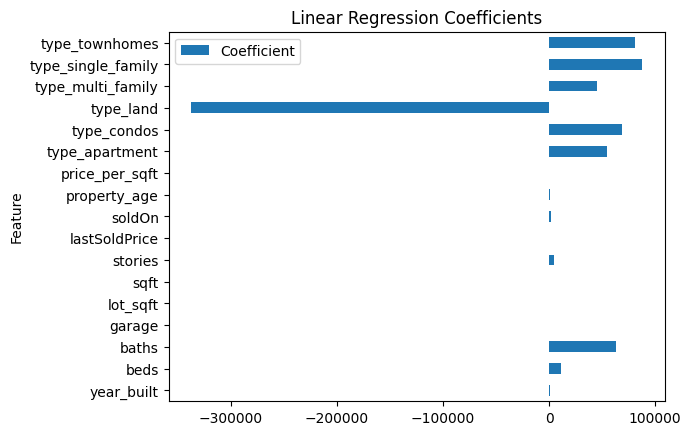

In [ ]:
lr_model.fit(X_train, y_train)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
})

coef_df.plot(kind='barh', x='Feature', y='Coefficient', title='Linear Regression Coefficients')
plt.show()

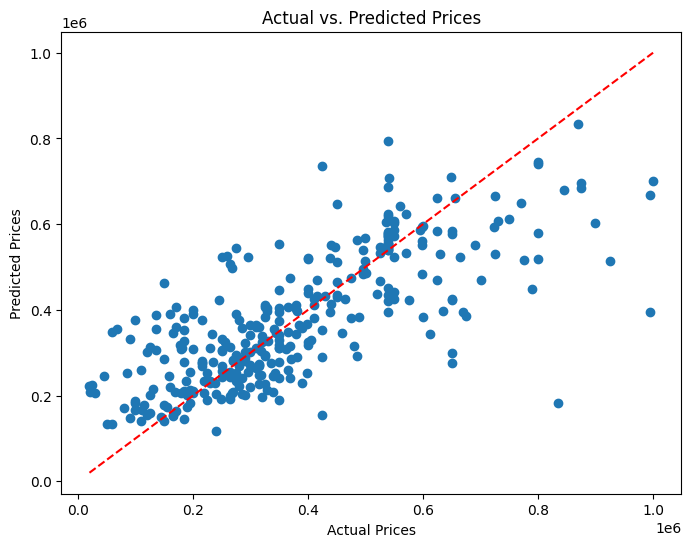

In [ ]:
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices')
plt.show()

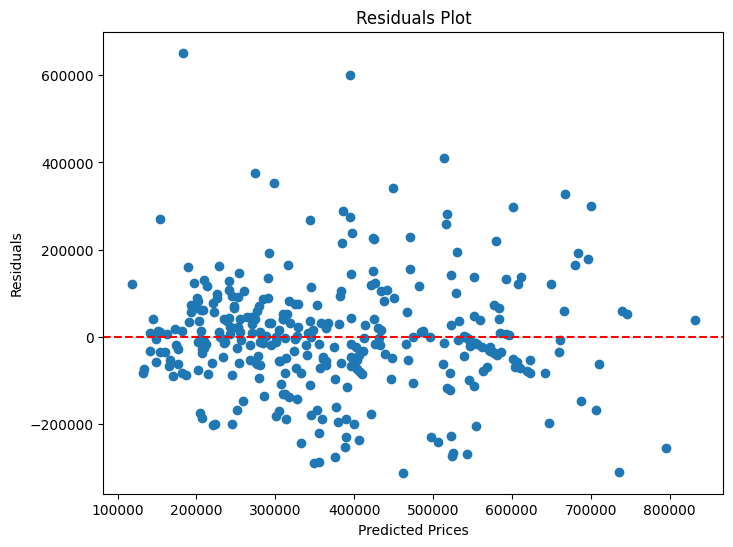

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.show()

### Random Forest Regressor

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)
rf_train_score = rf_model.score(X_train, y_train)
rf_test_score = rf_model.score(X_test, y_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error: {mse_rf}")
print(f"Random Forest - Root Mean Squared Error: {rmse_rf}")
print(f"Random Forest - R-squared: {r2_rf}")
print(f'Random Forest Training R^2 Score: {rf_train_score}')
print(f'Random Forest Test R^2 Score: {rf_test_score}')

Random Forest - Mean Squared Error: 17367888252.377552
Random Forest - Root Mean Squared Error: 131787.2841072975
Random Forest - R-squared: 0.5620222253153846
Random Forest Training R^2 Score: 0.9361236930654966
Random Forest Test R^2 Score: 0.5620222253153846


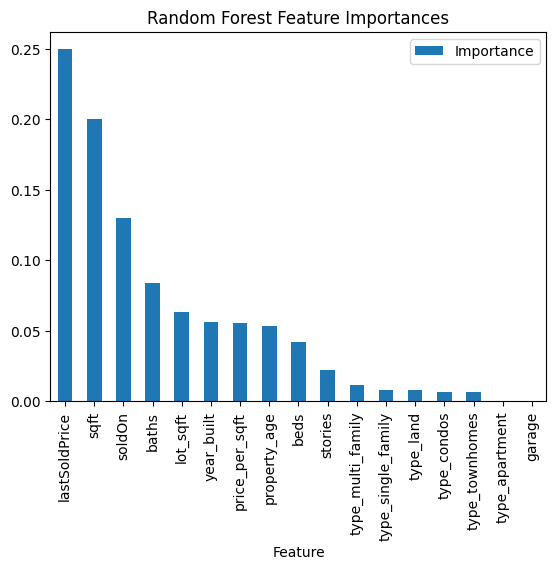

In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importances.plot(kind='bar', x='Feature', y='Importance', title='Random Forest Feature Importances')
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_random = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(rf_model, param_random, cv=5, scoring='r2')
random_search.fit(X_train, y_train)

print(f'Best Parameters: {random_search.best_params_}')

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}


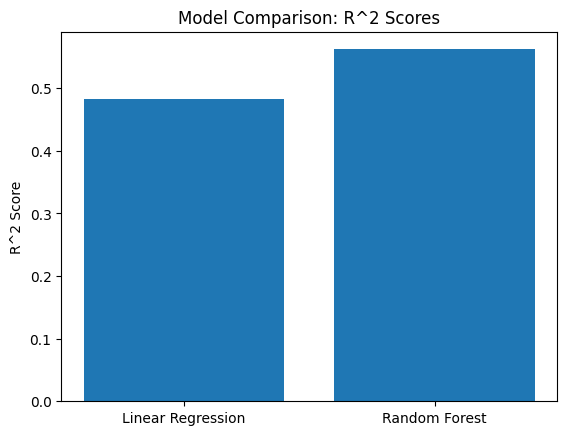

In [ ]:
models = ['Linear Regression', 'Random Forest']
scores = [lr_model.score(X_test, y_test), rf_model.score(X_test, y_test)]

plt.bar(models, scores)
plt.title('Model Comparison: R^2 Scores')
plt.ylabel('R^2 Score')
plt.show()

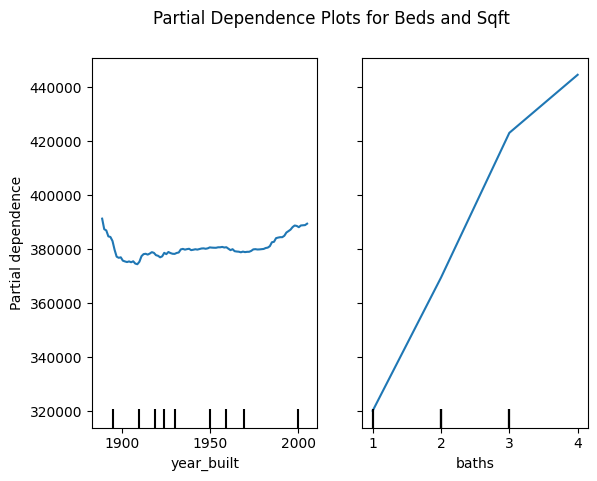

In [ ]:
# Instead of using the deprecated 'plot_partial_dependence', use 'PartialDependenceDisplay'
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

display = PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    features=[0, 2],
    feature_names=X_train.columns,

)
display.figure_.suptitle('Partial Dependence Plots for Beds and Sqft')
plt.show()

In [ ]:
from sklearn.ensemble import VotingRegressor

ensemble_model = VotingRegressor([('lr', lr_model), ('rf', rf_model)])
ensemble_model.fit(X_train, y_train)

ensemble_score = ensemble_model.score(X_test, y_test)
print(f'Ensemble Model Test R^2 Score: {ensemble_score}')

Ensemble Model Test R^2 Score: 0.5561674130614651


### Light GBM Regressor

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model_LGBM = LGBMRegressor(n_estimators=1000, learning_rate=0.05)
preprocessor = StandardScaler()

LGBM_Pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', model_LGBM)])
LGBM_Pipeline.fit(X_train, y_train)
preds_LGBM = LGBM_Pipeline.predict(X_test)

mse_lgbm = mean_squared_error(y_test, preds_LGBM)
r2_lgbm = r2_score(y_test, preds_LGBM)
mae_lgbm = mean_absolute_error(y_test, preds_LGBM)
print(f"Mean Squared Error: {mse_lgbm}")
print(f"R-squared: {r2_lgbm}")
print(f"Mean Absolute Error: {mae_lgbm}") # Print MAE

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000192 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1211
[LightGBM] [Info] Number of data points in the train set: 1300, number of used features: 14
[LightGBM] [Info] Start training from score 378854.775385
Mean Squared Error: 21529992976.455677
R-squared: 0.45706361788039507
Mean Absolute Error: 107124.01067936288


### XGBoost Regressor

In [ ]:
pip install xgboost

In [ ]:
# XGBoost Regressor
from xgboost import XGBRegressor

# Initialize the model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost - Mean Squared Error: {mse_xgb}")
print(f"XGBoost - Root Mean Squared Error: {rmse_xgb}")
print(f"XGBoost - R-squared: {r2_xgb}")

XGBoost - Mean Squared Error: 20222851127.943142
XGBoost - Root Mean Squared Error: 142207.071300773
XGBoost - R-squared: 0.49002671241760254


### CatBoost Regressor

In [ ]:
pip install catboost

In [ ]:
# CatBoost Regressor
from catboost import CatBoostRegressor

# Initialize the model
cat_model = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, random_seed=42, verbose=False)

# Train the model
cat_model.fit(X_train, y_train)

# Predict on the test set
y_pred_cat = cat_model.predict(X_test)

# Evaluate the model
mse_cat = mean_squared_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"CatBoost - Mean Squared Error: {mse_cat}")
print(f"CatBoost - Root Mean Squared Error: {rmse_cat}")
print(f"CatBoost - R-squared: {r2_cat}")

CatBoost - Mean Squared Error: 17039121153.173958
CatBoost - Root Mean Squared Error: 130533.98466749553
CatBoost - R-squared: 0.5703129674255543


In [ ]:
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

estimators = [
    ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.05)),
    ('lgbm', LGBMRegressor(n_estimators=100, learning_rate=0.05)),
    ('cat', CatBoostRegressor(iterations=100, learning_rate=0.05, verbose=False))
]

stack_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stack_model.fit(X_train, y_train)
y_pred_stack = stack_model.predict(X_test)
r2_stack = r2_score(y_test, y_pred_stack)
print(f"Stacking Model R^2: {r2_stack}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000311 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1313
[LightGBM] [Info] Number of data points in the train set: 1300, number of used features: 14
[LightGBM] [Info] Start training from score 378854.775385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000193 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1278
[LightGBM] [Info] Number of data points in the train set: 1040, number of used features: 14
[LightGBM] [Info] Start training from score 378502.194231
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1274
[LightGBM] [Info] Number of data points in the train set: 1040, number of used features: 14
[LightGBM] [Info] St

In [ ]:
from sklearn.ensemble import BaggingRegressor

# Replace 'base_estimator' with 'estimator'
bagged_model = BaggingRegressor(estimator=LGBMRegressor(n_estimators=100, learning_rate=0.05), n_estimators=10, random_state=42)
bagged_model.fit(X_train, y_train)
y_pred_bagged = bagged_model.predict(X_test)
r2_bagged = r2_score(y_test, y_pred_bagged)
print(f"Bagged LGBM R^2: {r2_bagged}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1313
[LightGBM] [Info] Number of data points in the train set: 1300, number of used features: 14
[LightGBM] [Info] Start training from score 378836.235385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1313
[LightGBM] [Info] Number of data points in the train set: 1300, number of used features: 14
[LightGBM] [Info] Start training from score 376611.333077
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1313
[LightGBM] [Info] Number of data points in the t

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV

# Define the AdaBoost model and parameter grid for tuning
adaboost_model = AdaBoostRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

# Use GridSearchCV for hyperparameter tuning
adaboost_grid = GridSearchCV(adaboost_model, param_grid, cv=5, scoring='r2')
adaboost_grid.fit(X_train, y_train)

# Get the best estimator and calculate R2 score
best_adaboost = adaboost_grid.best_estimator_
r2_adaboost = best_adaboost.score(X_test, y_test)

print(f"Optimized AdaBoost R^2 Score: {r2_adaboost}")

Optimized AdaBoost R^2 Score: 0.44333972885907635


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Fit the AdaBoost model with polynomial features
adaboost_model.fit(X_train_poly, y_train)

# Predict and evaluate
y_pred_poly = adaboost_model.predict(X_test_poly)

r2_poly_adaboost = adaboost_model.score(X_test_poly, y_test)
print(f"R^2 with Polynomial Features: {r2_poly_adaboost}")

rmse_poly_adaboost = np.sqrt(mean_squared_error(y_test, y_pred_poly))
print(f"RMSE with Polynomial Features: {rmse_poly_adaboost}")

R^2 with Polynomial Features: 0.4624264607945924
RMSE with Polynomial Features: 146004.55785683938


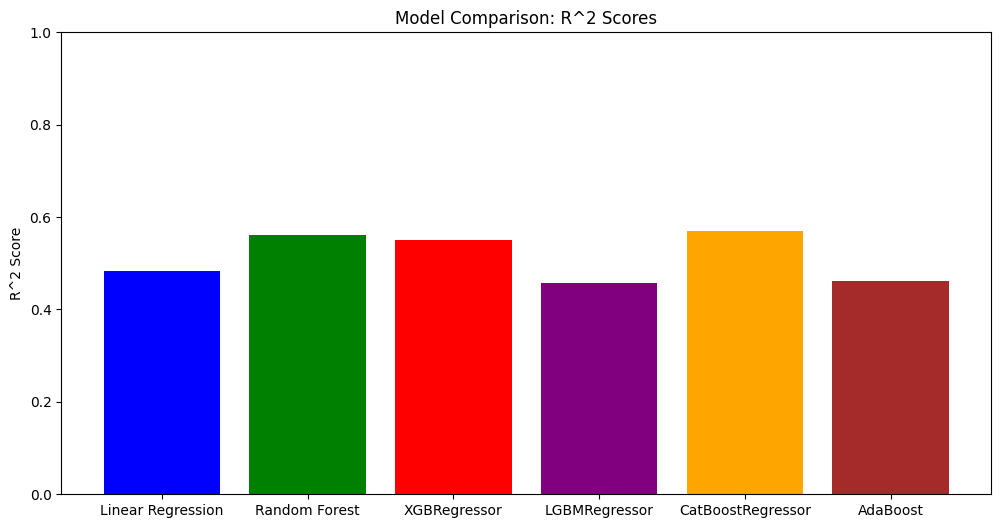

In [ ]:
# Append AdaBoost R^2 to the previous scores
models = ['Linear Regression', 'Random Forest', 'XGBRegressor', 'LGBMRegressor', 'CatBoostRegressor', 'AdaBoost']
scores = [
    lr_model.score(X_test, y_test),
    rf_model.score(X_test, y_test),
    r2_xgb,
    r2_lgbm,
    r2_cat,
    r2_poly_adaboost
]

plt.figure(figsize=(12, 6))
plt.bar(models, scores, color=['blue', 'green', 'red', 'purple', 'orange', 'brown'])
plt.title('Model Comparison: R^2 Scores')
plt.ylabel('R^2 Score')
plt.ylim(0, 1)
plt.show()

Implement a pipeline to ensure that data transformations are applied consistently across training and testing datasets:

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMRegressor(n_estimators=1000, learning_rate=0.05))
])
pipeline.fit(X_train, y_train)
preds_pipeline = pipeline.predict(X_test)
r2_pipeline = r2_score(y_test, preds_pipeline)
print(f"Pipeline R^2 Score: {r2_pipeline}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1211
[LightGBM] [Info] Number of data points in the train set: 1300, number of used features: 14
[LightGBM] [Info] Start training from score 378854.775385
Pipeline R^2 Score: 0.45706361788039507


### Visual Comparison of Models

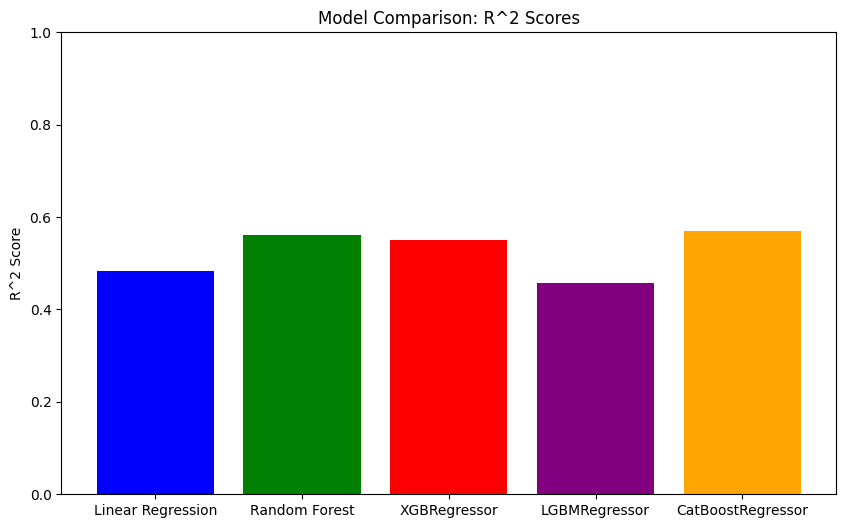

In [ ]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
r2_xgb = xgb_model.score(X_test, y_test)

models = ['Linear Regression', 'Random Forest', 'XGBRegressor', 'LGBMRegressor', 'CatBoostRegressor']
scores = [
    lr_model.score(X_test, y_test),
    rf_model.score(X_test, y_test),
    r2_xgb,
    r2_lgbm,
    r2_cat
]

plt.figure(figsize=(10, 6))
plt.bar(models, scores, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.title('Model Comparison: R^2 Scores')
plt.ylabel('R^2 Score')
plt.ylim(0, 1)
plt.show()

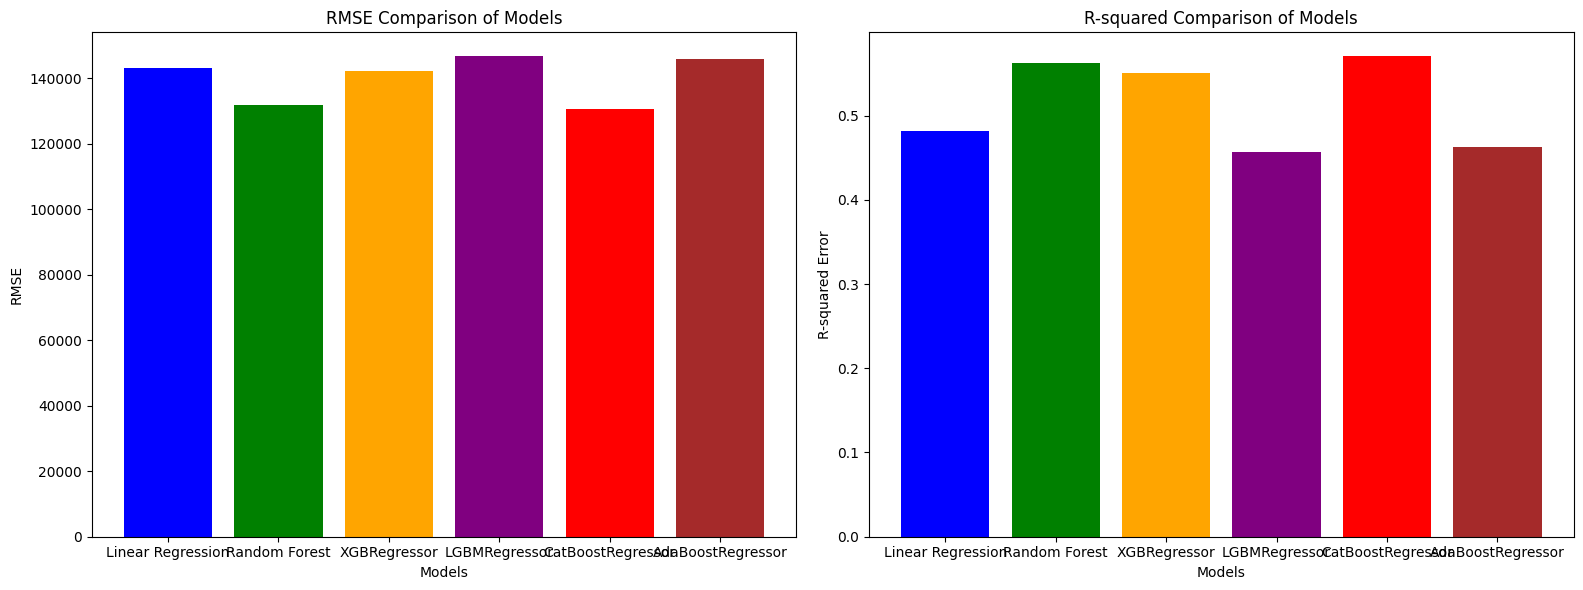

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
rmse_lgbm = np.sqrt(mean_squared_error(y_test, preds_pipeline))
# Model names
models = ['Linear Regression', 'Random Forest', 'XGBRegressor', 'LGBMRegressor', 'CatBoostRegressor', 'AdaBoostRegressor']

# RMSE values for each model
rmse_values = [rmse, rmse_rf, rmse_xgb, rmse_lgbm, rmse_cat, rmse_poly_adaboost]

# R-squared values for each model
# The r2_values list was missing the R-squared value for LGBMRegressor.
# Adding it here to match the number of models.
r2_values = [r2_lr, r2_rf, r2_xgb, r2_lgbm, r2_cat, r2_poly_adaboost]

# Plotting RMSE comparison
plt.figure(figsize=(16, 6))

# Subplot 1: RMSE Comparison
plt.subplot(1, 2, 1)
plt.bar(models, rmse_values, color=['blue', 'green', 'orange', 'purple', 'red', 'brown'])
plt.title('RMSE Comparison of Models')
plt.ylabel('RMSE')
plt.xlabel('Models')

# Subplot 2: R-squared Comparison
plt.subplot(1, 2, 2)
plt.bar(models, r2_values, color=['blue', 'green', 'orange', 'purple', 'red', 'brown'])
plt.title('R-squared Comparison of Models')
plt.ylabel('R-squared Error')
plt.xlabel('Models')

# Display both plots
plt.tight_layout()
plt.show()